<a href="https://colab.research.google.com/github/nicollas-byte/Big-Data/blob/main/analise_buscas_colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de desempenho de algoritmos de busca
**Busca sequencial, busca por saltos e busca binária — Google Colab**

Execute as células na ordem. O notebook mede tempos com `timeit`, conta comparações de chaves, produz gráficos e CSVs e analisa o custo de `np.sort`.

**Escopo:** as imagens fornecidas mostram N entre 50 e 1.000.000, mas não apresentam os arquivos nem a lista completa dos casos oficiais. Os dados abaixo são **demonstrativos**, com semente fixa. Substitua-os pelos oficiais na seção 3 quando disponíveis. Nenhum resultado de desempenho ou limite de RAM foi inventado.

A seção de RAM inclui estimativa, teste limitado e teste de esgotamento opcional. O teste de esgotamento pode reiniciar a sessão: execute-o por último e guarde os resultados antes.

**Resultados já visíveis:** este arquivo contém tabelas e curvas executadas em um ambiente Linux local. Os tempos salvos NÃO foram medidos no Google Colab. Execute novamente no Colab para obter as medições da sua sessão. Os dados continuam demonstrativos, não oficiais.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import timeit, math, gc, json, os, platform, sys
from pathlib import Path
from datetime import datetime, timezone
from IPython.display import display

SEMENTE = 42
TAMANHOS = [50, 100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]
AMOSTRAS_MEDIO = 8  # aumente para 30 ou mais para uma média mais representativa
REPETICOES = 3
PASTA = Path('resultados_buscas')
PASTA.mkdir(exist_ok=True)
print('Python:', sys.version.split()[0], '| NumPy:', np.__version__)
print('Sistema:', platform.platform(), '| CPU:', platform.processor())
print('Data UTC:', datetime.now(timezone.utc).isoformat())


Python: 3.12.14 | NumPy: 2.3.5
Sistema: Linux-6.18.35-x86_64-with-glibc2.39 | CPU: x86_64
Data UTC: 2026-09-11T00:51:43.993136+00:00


## 1. Algoritmos
Cada função devolve `(índice, num_cmp)`. Se não encontrar, o índice é `-1`.
Contamos cada comparação entre uma chave do vetor e o alvo (`==` ou `<`). Testes de índices, limites e condições do laço não entram na contagem. O tempo inclui a instrumentação de contagem, igual em todas as medições. Os índices das buscas por saltos e binária referem-se ao **vetor ordenado**, não ao original.

Busca sequencial aceita dados não ordenados. Saltos e binária exigem ordenação crescente.


In [ ]:
def busca_sequencial(vetor, alvo):
    num_cmp = 0
    for i in range(len(vetor)):
        num_cmp += 1
        if vetor[i] == alvo:
            return i, num_cmp
    return -1, num_cmp


def busca_saltos(vetor, alvo):
    n = len(vetor)
    num_cmp = 0
    if n == 0:
        return -1, num_cmp
    passo = max(1, math.isqrt(n))
    inicio = 0
    fim = min(passo, n)
    while True:
        num_cmp += 1
        if vetor[fim - 1] < alvo:
            inicio = fim
            if inicio >= n:
                return -1, num_cmp
            fim = min(fim + passo, n)
        else:
            break
    for i in range(inicio, fim):
        num_cmp += 1
        if vetor[i] == alvo:
            return i, num_cmp
        num_cmp += 1
        if alvo < vetor[i]:
            return -1, num_cmp
    return -1, num_cmp


def busca_binaria(vetor, alvo):
    esquerda, direita = 0, len(vetor) - 1
    num_cmp = 0
    while esquerda <= direita:
        meio = (esquerda + direita) // 2
        num_cmp += 1
        if vetor[meio] == alvo:
            return meio, num_cmp
        num_cmp += 1
        if vetor[meio] < alvo:
            esquerda = meio + 1
        else:
            direita = meio - 1
    return -1, num_cmp

ALGORITMOS = {'Sequencial': busca_sequencial, 'Saltos': busca_saltos, 'Binária': busca_binaria}


## 2. Verificação de correção antes de medir


In [ ]:
rng_teste = np.random.default_rng(SEMENTE)
for n in [0, 1, 2, 3, 10, 49, 50, 51, 100]:
    v = np.sort(rng_teste.integers(-20, 21, size=n, dtype=np.int64))
    for alvo in range(-22, 23):
        esperado = bool(np.any(v == alvo))
        for nome, funcao in ALGORITMOS.items():
            indice, comparacoes = funcao(v, alvo)
            assert (indice != -1) == esperado, (nome, n, alvo)
            assert indice == -1 or v[indice] == alvo
            assert comparacoes >= 0
assert busca_sequencial([10, 20, 30], 30) == (2, 3)
assert busca_binaria([10, 20, 30], 20) == (1, 1)
print('Testes aprovados: vazios, repetidos, negativos, extremos e alvos ausentes.')


Testes aprovados: vazios, repetidos, negativos, extremos e alvos ausentes.


## 3. Dados demonstrativos ou casos oficiais
Nos demonstrativos, utilizamos chaves únicas pares em ordem crescente. Isso controla a posição e permite alvos ausentes entre as chaves. O caso médio amostra uniformemente **buscas bem-sucedidas**; não representa toda distribuição possível.

Cenários: primeiro elemento; último elemento; ausente acima do máximo; ausente entre as duas últimas chaves; médio bem-sucedido. Nenhum único alvo é necessariamente o pior caso para os três algoritmos. Em especial, saltos pode descartar rapidamente um alvo acima do máximo.

Para os oficiais, altere `USAR_OFICIAIS` e envie um JSON com esta estrutura (exemplo de formato, **não um caso oficial**):
```json
[{"nome":"caso_1","dados":[8,2,6,4],"alvos":[2,7,8]}]
```
Preservamos a ordem original para a sequencial; ordenamos uma cópia para as outras. Se o professor fornecer outro formato, adapte o carregamento sem alterar os valores.


In [ ]:
USAR_OFICIAIS = False
CASOS_OFICIAIS = []
if USAR_OFICIAIS:
    from google.colab import files
    enviados = files.upload()
    for conteudo in enviados.values():
        casos = json.loads(conteudo.decode('utf-8'))
        for caso in casos:
            dados = np.asarray(caso['dados'])
            assert dados.ndim == 1 and dados.dtype.kind in 'iu', 'Use vetores de inteiros.'
            assert len(dados) > 0 and len(caso['alvos']) > 0
            CASOS_OFICIAIS.append(caso)
    assert CASOS_OFICIAIS, 'Nenhum caso carregado.'
    print('Casos oficiais carregados:', len(CASOS_OFICIAIS))
else:
    print('Modo demonstrativo. Os casos oficiais ainda não foram fornecidos.')


Modo demonstrativo. Os casos oficiais ainda não foram fornecidos.


## 4. Medição com timeit
Usamos a mediana de três repetições. Cada repetição executa um lote de buscas; o tempo do lote é dividido pelo número de buscas. Lotes para funções rápidas reduzem o efeito da resolução do relógio. Não há geração de dados, ordenação, gráficos ou validação dentro do trecho cronometrado.

Os tempos também incluem chamadas de função, controle do lote e contagem. Compare tendências e repetições; não interprete pequenas diferenças como garantidas.


In [ ]:
def medir(funcao, vetor, alvos):
    alvos = [int(a) for a in alvos]
    estimativa = timeit.timeit(lambda: funcao(vetor, alvos[0]), number=1)
    lotes = max(1, min(1000, int(0.01 / max(estimativa * len(alvos), 1e-9))))
    def lote():
        for alvo in alvos:
            funcao(vetor, alvo)
    tempos = np.array(timeit.repeat(lote, number=lotes, repeat=REPETICOES)) / (lotes * len(alvos))
    return float(np.median(tempos)), float(tempos.min()), float(tempos.max())


def conjuntos():
    rng = np.random.default_rng(SEMENTE)
    if USAR_OFICIAIS:
        for caso in CASOS_OFICIAIS:
            yield caso['nome'], np.asarray(caso['dados']), {'Oficial': caso['alvos']}
    else:
        for n in TAMANHOS:
            v = np.arange(n, dtype=np.int64) * 2
            cenarios = {
                'Primeiro': [int(v[0])],
                'Último': [int(v[-1])],
                'Ausente acima': [int(v[-1]) + 1],
                'Ausente interno final': [int(v[-1]) - 1],
                'Médio bem-sucedido': v[rng.integers(0, n, AMOSTRAS_MEDIO)].tolist(),
            }
            yield f'demo_{n}', v, cenarios

linhas = []
for caso, original, cenarios in conjuntos():
    ordenado = np.sort(original)
    for cenario, alvos in cenarios.items():
        for nome, funcao in ALGORITMOS.items():
            v = original if nome == 'Sequencial' else ordenado
            contagens = []
            for alvo in alvos:
                indice, cmp = funcao(v, int(alvo))
                assert (indice >= 0) == bool(np.any(v == alvo))
                assert indice < 0 or v[indice] == alvo
                contagens.append(cmp)
            mediana, minimo, maximo = medir(funcao, v, alvos)
            linhas.append(dict(caso=caso, N=len(v), cenario=cenario, algoritmo=nome,
                               tempo_s=mediana, tempo_min_s=minimo, tempo_max_s=maximo,
                               num_cmp=float(np.mean(contagens)), cmp_max=max(contagens),
                               quantidade_alvos=len(alvos)))
    pd.DataFrame(linhas).to_csv(PASTA / 'desempenho.csv', index=False)
    print('Concluído:', caso, '| N =', len(original))
df = pd.DataFrame(linhas)
print('Medições concluídas. As tabelas completas aparecem na seção seguinte.')
del original, ordenado, v
gc.collect()


Concluído: demo_50 | N = 50
Concluído: demo_100 | N = 100
Concluído: demo_500 | N = 500
Concluído: demo_1000 | N = 1000
Concluído: demo_5000 | N = 5000
Concluído: demo_10000 | N = 10000
Concluído: demo_50000 | N = 50000
Concluído: demo_100000 | N = 100000
Concluído: demo_500000 | N = 500000
Concluído: demo_1000000 | N = 1000000
Medições concluídas. As tabelas completas aparecem na seção seguinte.


## 5. Tabelas de desempenho — buscas e tempo de cada uma
Cada linha compara as três buscas para o mesmo número de registros. Os valores são o **tempo mediano por busca, em milissegundos (ms)**, incluindo a contagem de comparações. Há uma tabela para cada cenário e, abaixo, a tabela completa com tempos e comparações.

**Origem das saídas salvas:** execução local, com os tamanhos completos de 50 a 1.000.000. Ao executar no Colab, os resultados serão substituídos pelos da sua sessão.


In [ ]:
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')
tabela_completa = df.copy()
tabela_completa['tempo_ms'] = tabela_completa['tempo_s'] * 1000
for cenario in tabela_completa['cenario'].unique():
    print(f'\n{cenario.upper()} — tempo por busca (ms)')
    parte = tabela_completa[tabela_completa['cenario'] == cenario]
    tabela = parte.pivot(index=['caso', 'N'], columns='algoritmo', values='tempo_ms')
    tabela = tabela.reindex(columns=['Sequencial', 'Saltos', 'Binária']).sort_index(level='N')
    display(tabela)
    identificador = list(tabela_completa.cenario.unique()).index(cenario)
    tabela.to_csv(PASTA / f'tabela_tempos_{identificador}.csv')
print('\nTABELA COMPLETA — tempo (ms) e comparações por busca')
display(tabela_completa[['N', 'caso', 'cenario', 'algoritmo', 'tempo_ms', 'num_cmp', 'cmp_max']])
tabela_completa.to_csv(PASTA / 'tabela_completa_tempos_comparacoes.csv', index=False)


Primeiro — tempos em ms


,algoritmo,Sequencial,Saltos,Binária
caso,N,,,
demo_50,50,0.000203,0.000466,0.001069
demo_100,100,0.000210,0.000477,0.001083
demo_500,500,0.000240,0.000501,0.001574
demo_1000,1000,0.000225,0.000524,0.001826
demo_5000,5000,0.000220,0.000502,0.002386
demo_10000,10000,0.000222,0.000513,0.002675
demo_50000,50000,0.000224,0.000507,0.003114
demo_100000,100000,0.000223,0.000514,0.003286
demo_500000,500000,0.000223,0.000536,0.003627


Último — tempos em ms


,algoritmo,Sequencial,Saltos,Binária
caso,N,,,
demo_50,50,0.003899,0.001488,0.001076
demo_100,100,0.007861,0.003206,0.001265
demo_500,500,0.043930,0.006717,0.001952
demo_1000,1000,0.096288,0.007042,0.002223
demo_5000,5000,0.467632,0.017449,0.002826
demo_10000,10000,1.038857,0.036456,0.003288
demo_50000,50000,4.566133,0.046323,0.003587
demo_100000,100000,9.571336,0.082681,0.003776
demo_500000,500000,46.055838,0.151709,0.004169


Ausente acima — tempos em ms


...

,algoritmo,Sequencial,Saltos,Binária
caso,N,,,
demo_50,50,0.003967,0.001563,0.001156
demo_100,100,0.008099,0.003168,0.001337
demo_500,500,0.044195,0.006721,0.002078
demo_1000,1000,0.090560,0.007520,0.002289
demo_5000,5000,0.476333,0.017715,0.002973
demo_10000,10000,0.969050,0.036613,0.003903
demo_50000,50000,5.489550,0.050395,0.003685
demo_100000,100000,9.311786,0.080403,0.003784
demo_500000,500000,51.559840,0.172484,0.004393


Médio bem-sucedido — tempos em ms


,algoritmo,Sequencial,Saltos,Binária
caso,N,,,
demo_50,50,0.002021,0.001248,0.001045
demo_100,100,0.004693,0.001896,0.001090
demo_500,500,0.020398,0.003411,0.001577
demo_1000,1000,0.047168,0.006167,0.001939
demo_5000,5000,0.254044,0.012756,0.002574
demo_10000,10000,0.535230,0.019550,0.003170
demo_50000,50000,2.280667,0.046129,0.003430
demo_100000,100000,6.277686,0.065779,0.003249
demo_500000,500000,22.584465,0.141207,0.003912


Tabela completa — tempo e comparações — tempos em ms


,N,caso,cenario,algoritmo,tempo_ms,num_cmp,cmp_max
0,50,demo_50,Primeiro,Sequencial,0.000203,1.000000,1
1,50,demo_50,Primeiro,Saltos,0.000466,2.000000,2
2,50,demo_50,Primeiro,Binária,0.001069,9.000000,9
3,50,demo_50,Último,Sequencial,0.003899,50.000000,50
4,50,demo_50,Último,Saltos,0.001488,9.000000,9
5,50,demo_50,Último,Binária,0.001076,11.000000,11
6,50,demo_50,Ausente acima,Sequencial,0.003884,50.000000,50
7,50,demo_50,Ausente acima,Saltos,0.001363,8.000000,8
8,50,demo_50,Ausente acima,Binária,0.001164,12.000000,12
9,50,demo_50,Ausente interno final,Sequencial,0.003967,50.000000,50


## 5.1. Curvas de desempenho

À esquerda: tempo de cada busca em função de N. À direita: comparações de chaves. Os eixos logarítmicos permitem enxergar as três curvas apesar das diferenças de escala.


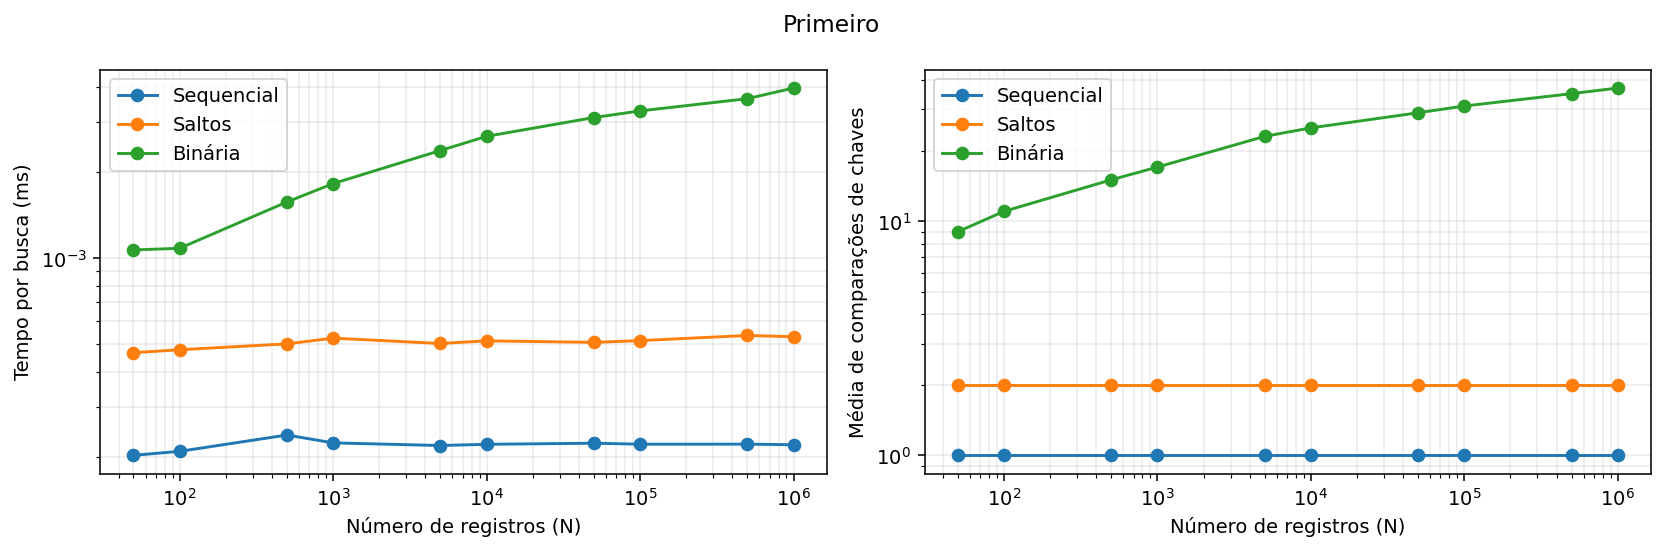

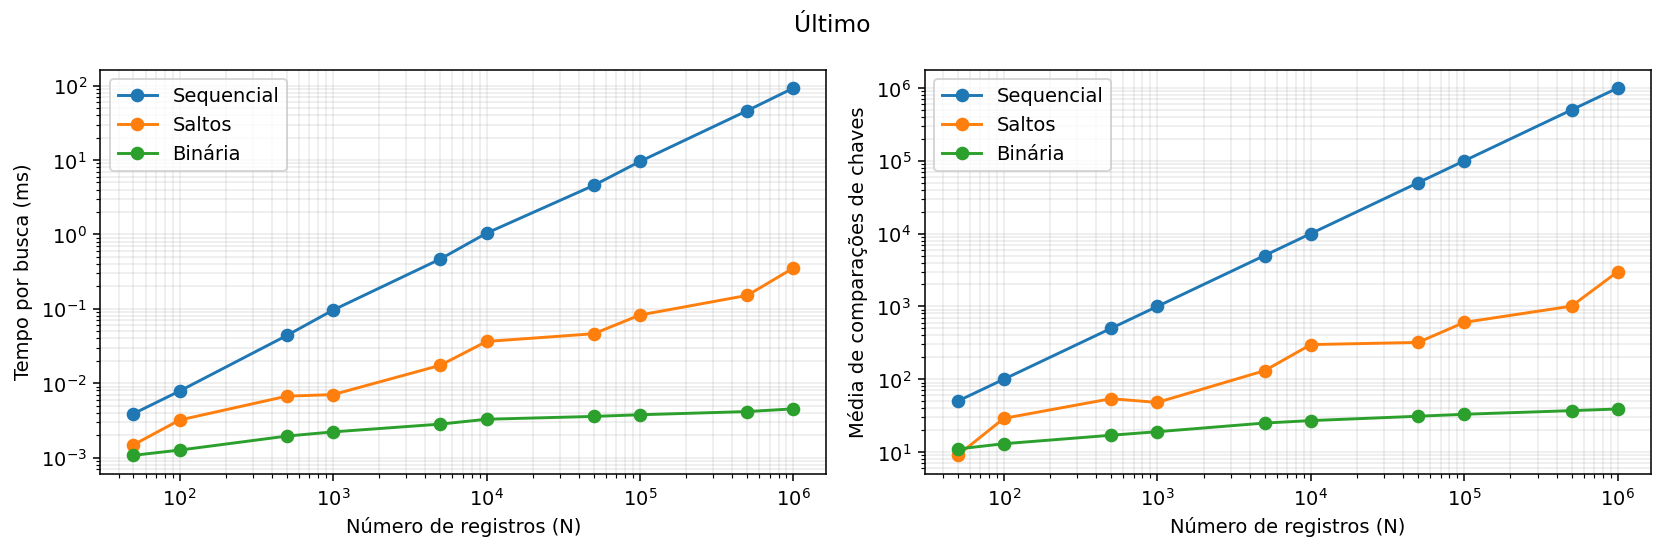

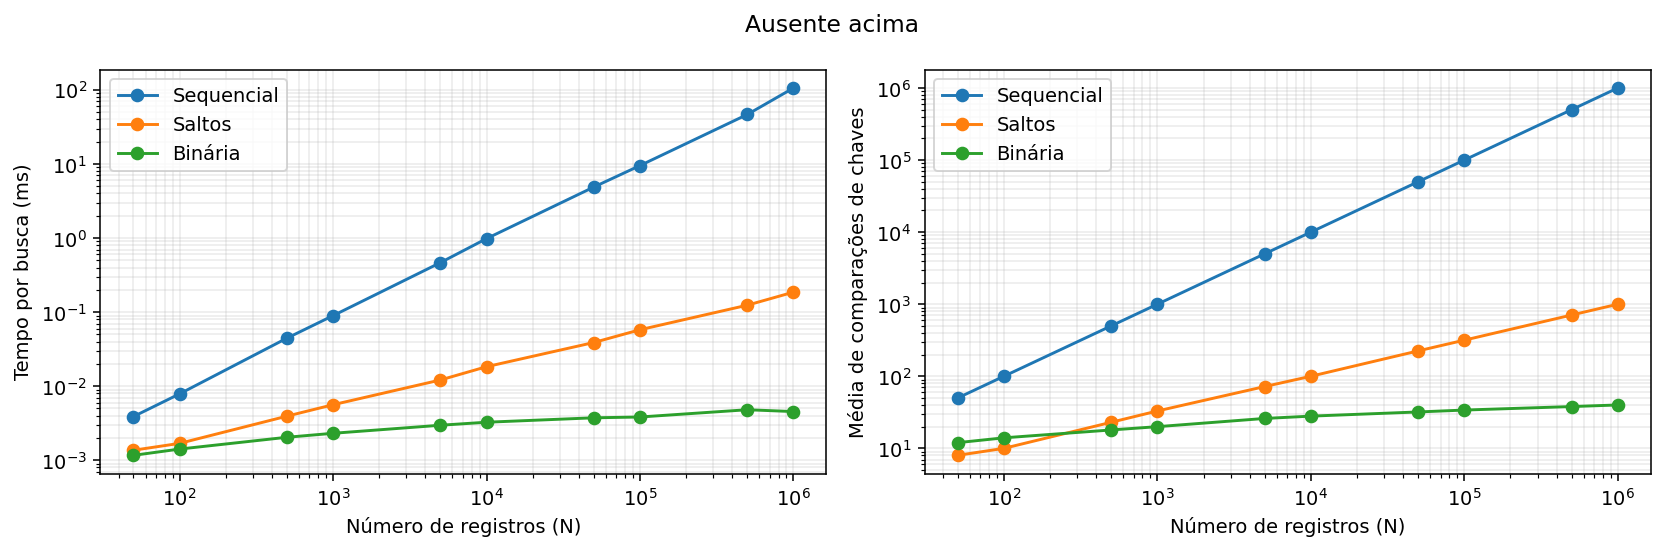

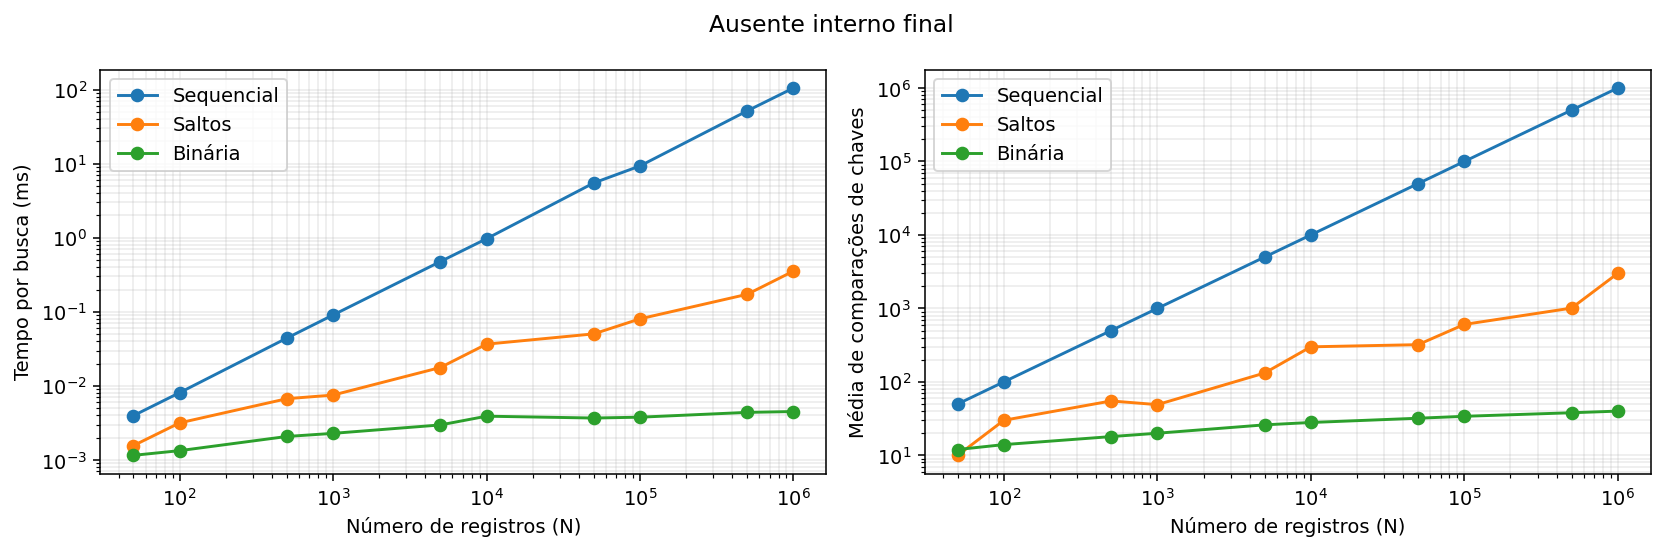

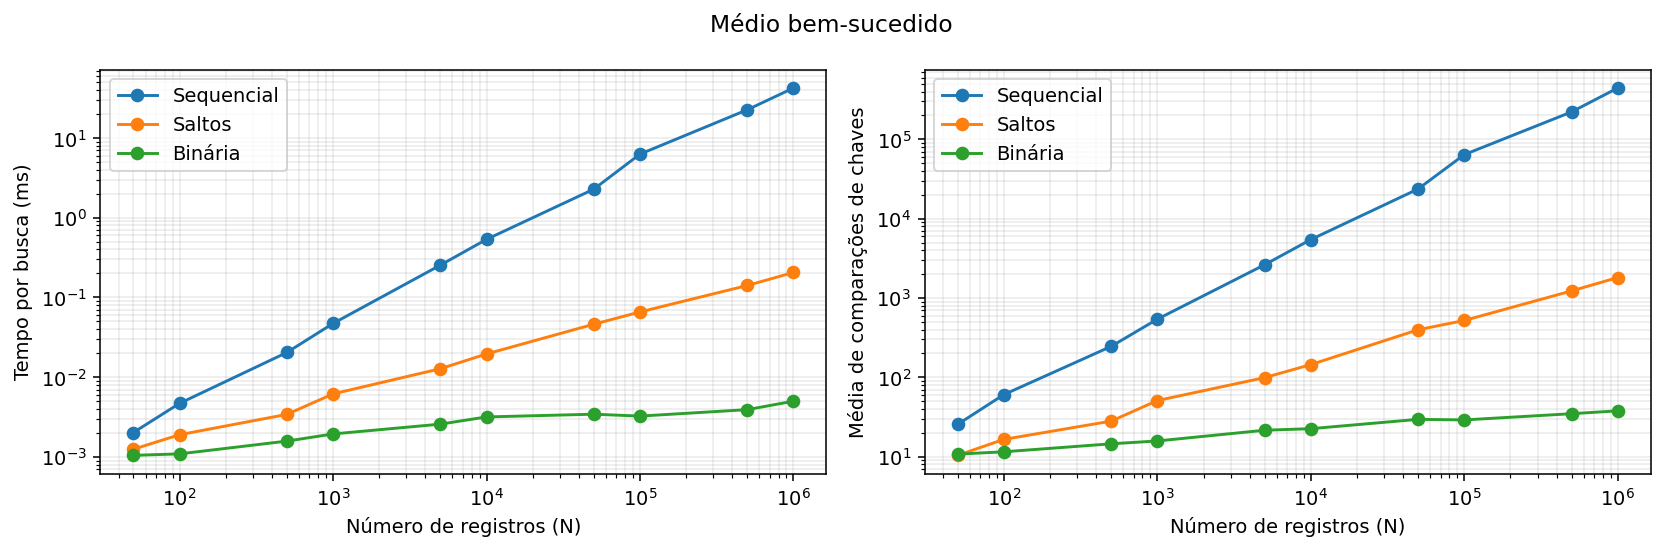

In [ ]:
for cenario in df['cenario'].unique():
    fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
    parte = df[df['cenario'] == cenario]
    for nome in ALGORITMOS:
        dados = parte[parte['algoritmo'] == nome].sort_values('N')
        eixos[0].plot(dados['N'], dados['tempo_s'] * 1000, 'o-', label=nome)
        eixos[1].plot(dados['N'], dados['num_cmp'], 'o-', label=nome)
    for eixo, ylabel in zip(eixos, ['Tempo por busca (ms)', 'Média de comparações de chaves']):
        eixo.set(xscale='log', yscale='log', xlabel='Número de registros (N)', ylabel=ylabel)
        eixo.grid(True, which='both', alpha=.25)
        eixo.legend()
    fig.suptitle(cenario)
    fig.tight_layout()
    fig.savefig(PASTA / f'curva_{list(df.cenario.unique()).index(cenario)}.png', dpi=160)
    plt.show()


## 6. Custo oculto da ordenação
Compare duas estratégias no **mesmo conjunto inicialmente desordenado**: sequencial sem ordenar; ordenar uma única vez e realizar saltos/binária. Usamos o mesmo lote de alvos nas três buscas.

Medimos `np.sort` separadamente e estimamos `T_total(q) = T_sort + q × T_busca`. A estratégia sequencial usa `q × T_sequencial`. As curvas para milhares de consultas são **projeções dos tempos medidos**, não execução de milhares de buscas. Supõem dados estáticos e consultas com distribuição semelhante; atualizações podem exigir nova ordenação.

O ponto de equilíbrio estimado é `ceil(T_sort / (T_sequencial − T_busca))`, quando a diferença é positiva. O custo de ordenação inclui a cópia criada por `np.sort`.


N = 100,000; np.sort = 0.003864 s
Saltos | consultas para compensar a ordenação (estimativa): 2
Binária | consultas para compensar a ordenação (estimativa): 2


,consultas,Sequencial,Saltos,Binária
0,1,0.003344,0.003917,0.003868
1,2,0.006688,0.003970,0.003872
2,5,0.016721,0.004130,0.003883
3,10,0.033441,0.004395,0.003903
4,50,0.167206,0.006522,0.004059
5,100,0.334411,0.009181,0.004255
6,500,1.672055,0.030451,0.005821
7,1000,3.344111,0.057038,0.007778
8,5000,16.720554,0.269735,0.023434
9,10000,33.441109,0.535607,0.043005


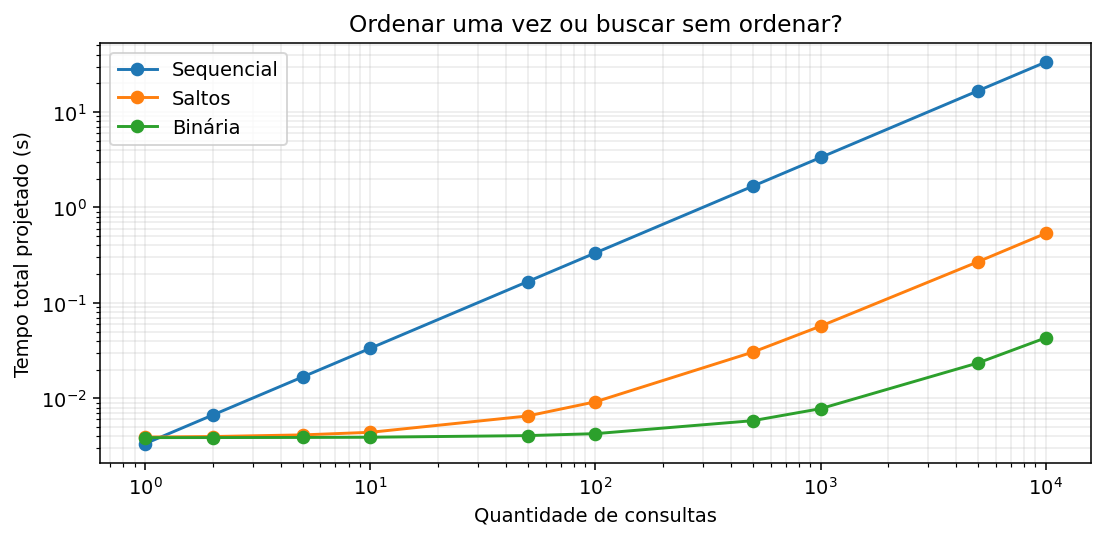

In [ ]:
rng = np.random.default_rng(SEMENTE)
N_CUSTO = 100_000
base = rng.permutation(N_CUSTO).astype(np.int64)
alvos_custo = base[rng.integers(0, N_CUSTO, AMOSTRAS_MEDIO)].tolist()
t_sort = float(np.median(timeit.repeat(lambda: np.sort(base), number=1, repeat=REPETICOES)))
base_ordenada = np.sort(base)
t_busca = {}
for nome, funcao in ALGORITMOS.items():
    t_busca[nome] = medir(funcao, base if nome == 'Sequencial' else base_ordenada, alvos_custo)[0]
print(f'N = {N_CUSTO:,}; np.sort = {t_sort:.6f} s')
for nome in ['Saltos', 'Binária']:
    diferenca = t_busca['Sequencial'] - t_busca[nome]
    ponto = math.ceil(t_sort / diferenca) if diferenca > 0 else None
    print(nome, '| consultas para compensar a ordenação (estimativa):', ponto)
qs = np.array([1, 2, 5, 10, 50, 100, 500, 1_000, 5_000, 10_000])
custo = pd.DataFrame({'consultas': qs})
for nome in ALGORITMOS:
    custo[nome] = qs * t_busca[nome] + (0 if nome == 'Sequencial' else t_sort)
custo.to_csv(PASTA / 'custo_ordenacao_projetado.csv', index=False)
(PASTA / 'medicoes_custo.json').write_text(json.dumps({'N': N_CUSTO, 'ordenacao_s': t_sort, 'busca_s': t_busca}, indent=2))
display(custo)
ax = custo.plot(x='consultas', logx=True, logy=True, marker='o', figsize=(8, 4))
ax.set(xlabel='Quantidade de consultas', ylabel='Tempo total projetado (s)', title='Ordenar uma vez ou buscar sem ordenar?')
ax.grid(True, which='both', alpha=.25)
plt.tight_layout()
plt.savefig(PASTA / 'custo_ordenacao.png', dpi=160)
plt.show()
del base, base_ordenada
gc.collect()


## 7. Interpretação para o relatório
| Algoritmo | Melhor caso | Caso médio¹ | Pior caso | Ordenação prévia |
|---|---|---|---|---|
| Sequencial | O(1) | O(N) | O(N) | Não |
| Saltos, passo √N | O(1) | O(√N) | O(√N) | Sim |
| Binária | O(1) | O(log N) | O(log N) | Sim |

¹ Considerando alvos presentes com posições uniformemente distribuídas e chaves distintas. Para a sequencial, a média teórica é `(N+1)/2` comparações de igualdade. A amostra experimental pode divergir.

- **Pior caso e caso médio:** a sequencial percorre N posições para um ausente ou alvo no final. Na binária, o primeiro elemento não é geralmente o melhor caso: é o elemento central. Saltos combina inspeção das extremidades dos blocos com varredura local; um ausente acima do máximo só exige os saltos. Para observar um cenário mais caro, compare também o ausente interno próximo ao final. Os cenários escolhidos não provam um máximo exato de comparações para cada N.
- **Tempo e comparações:** redução de comparações não determina sozinha o tempo: laços Python, acessos NumPy e ruído da máquina também pesam.
- **Poucas versus milhares de buscas:** use os pontos de equilíbrio medidos. Ordenar pode não compensar para poucas consultas e pode compensar quando seu custo se dilui; não existe um número universal.
- **Comparabilidade:** os algoritmos de busca estão implementados em Python, enquanto `np.sort` usa código compilado. O experimento compara estas implementações concretas.

No texto final, cite valores de N, tempos, comparações, hardware disponível, repetições e distribuição de alvos. Não chame os demonstrativos de oficiais.


## 8. RAM: estimativa do limite da sessão
Um vetor `int64` ocupa `8 × N` bytes de elementos. Um milhão ocupa aproximadamente 7,63 MiB. Manter o original e o resultado de `np.sort` exige pelo menos `16 × N` bytes, além do interpretador e estruturas temporárias.

A leitura abaixo considera a RAM disponível do Linux e, quando exposto, o limite do contêiner. O teto calculado é uma **estimativa**, não um estouro observado. A memória atribuída à sessão varia; memória virtual alocada não significa páginas físicas efetivamente usadas.


In [ ]:
def memoria_sessao():
    campos = {}
    for linha in Path('/proc/meminfo').read_text().splitlines():
        chave, valor = linha.split(':', 1)
        campos[chave] = int(valor.split()[0]) * 1024
    total = campos['MemTotal']
    disponivel = campos['MemAvailable']
    limite = None
    for arq_limite, arq_uso in [('/sys/fs/cgroup/memory.max', '/sys/fs/cgroup/memory.current'),
                               ('/sys/fs/cgroup/memory/memory.limit_in_bytes', '/sys/fs/cgroup/memory/memory.usage_in_bytes')]:
        try:
            l = int(Path(arq_limite).read_text().strip())
            uso = int(Path(arq_uso).read_text().strip())
            if 0 < l < total:
                limite = l
                disponivel = min(disponivel, max(0, l - uso))
                total = l
        except (OSError, ValueError):
            pass
    return {'total_efetivo_bytes': total, 'disponivel_bytes': disponivel, 'limite_cgroup_bytes': limite}

mem = memoria_sessao()
print(json.dumps(mem, indent=2))
reserva = max(512 * 1024**2, int(mem['total_efetivo_bytes'] * .2))
orcamento = max(0, mem['disponivel_bytes'] - reserva)
print('Teto estimado com reserva, um vetor int64:', orcamento // 8, 'elementos')
print('Teto estimado com reserva, original + ordenado:', orcamento // 16, 'elementos')
(PASTA / 'memoria_ambiente.json').write_text(json.dumps(mem, indent=2))


{
  "total_efetivo_bytes": 15032385536,
  "disponivel_bytes": 14769999872,
  "limite_cgroup_bytes": 15032385536
}
Teto estimado com reserva, um vetor int64: 1470440345 elementos
Teto estimado com reserva, original + ordenado: 735220172 elementos


## 9. Experimento de RAM — execute por último
O modo padrão aloca e **preenche** até 256 MiB adicionais para verificar o procedimento. **Não mede o ponto de estouro.**

Para investigar esgotamento real no Colab, salve primeiro os CSVs e gráficos (seção 10), monte o Drive com a célula abaixo e altere `TESTAR_ATE_FALHAR = True`. O processo pode ser encerrado pelo sistema sem lançar `MemoryError`, reiniciando a sessão. O teste registra cada tentativa **antes** da alocação e cada sucesso **depois** do preenchimento, com `flush` e `fsync`.

Após reiniciar, consulte o CSV no Drive. Um último `tentativa` sem `sucesso` indica interrupção durante aquele bloco; só classifique como falta de RAM se o Colab também indicar esgotamento. Anote a mensagem ou capture a tela. O último sucesso fornece um limite inferior; o próximo bloco fornece o limite superior aproximado, não um limite físico exato. O teste mede blocos adicionais de arrays nesta sessão, não o maior vetor contíguo possível nem o pico da ordenação. Swap e outras cargas podem alterar o resultado.


In [ ]:
# Opcional: execute antes do teste de esgotamento para tornar o registro persistente.
MONTAR_DRIVE = False
if MONTAR_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')


In [ ]:
TESTAR_ATE_FALHAR = False
BLOCO_MIB = 64
LIMITE_SEGURO_MIB = 256


def testar_ram():
    import csv
    if TESTAR_ATE_FALHAR:
        drive_root = Path('/content/drive/MyDrive')
        if not drive_root.is_dir():
            raise RuntimeError('Monte o Drive na célula anterior para preservar o registro.')
        destino = drive_root / 'experimento_buscas_ram'
    else:
        destino = PASTA
    destino.mkdir(exist_ok=True)
    caminho = destino / ('ram_' + datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S') + '.csv')
    blocos = []
    total = 0
    passo_bytes = BLOCO_MIB * 1024**2
    print('Registro:', caminho)
    try:
        with caminho.open('w', newline='') as arquivo:
            campos = ['data_utc', 'evento', 'adicional_alvo_bytes', 'disponivel_bytes']
            writer = csv.DictWriter(arquivo, fieldnames=campos)
            writer.writeheader()
            def registrar(evento, alvo):
                writer.writerow(dict(data_utc=datetime.now(timezone.utc).isoformat(), evento=evento,
                                     adicional_alvo_bytes=alvo, disponivel_bytes=memoria_sessao()['disponivel_bytes']))
                arquivo.flush()
                os.fsync(arquivo.fileno())
            while True:
                proximo = total + passo_bytes
                if not TESTAR_ATE_FALHAR:
                    disponivel = memoria_sessao()['disponivel_bytes']
                    if proximo > LIMITE_SEGURO_MIB * 1024**2 or disponivel - passo_bytes < reserva:
                        registrar('parada_preventiva_sem_estouro', total)
                        break
                registrar('tentativa', proximo)
                try:
                    bloco = np.empty(passo_bytes // 8, dtype=np.int64)
                    bloco.fill(1)  # toca as páginas: não basta reservar memória virtual
                    blocos.append(bloco)
                    del bloco
                except MemoryError:
                    registrar('MemoryError', proximo)
                    print('MemoryError observado. Veja o intervalo no CSV.')
                    break
                total = proximo
                registrar('sucesso', total)
                print('Alocado e preenchido:', total // 1024**2, 'MiB', flush=True)
    finally:
        blocos.clear()
        gc.collect()
    print('Teste concluído. Registro:', caminho)
    return caminho

caminho_ram = testar_ram()


## 10. Baixar resultados
Execute antes do teste de esgotamento e novamente após um teste limitado. O ZIP contém os arquivos produzidos nesta sessão. O log de esgotamento, quando ativado, fica na pasta `experimento_buscas_ram` do seu Drive.

**Checklist da entrega:** implementar as três buscas; executar os casos oficiais quando recebidos; apresentar tempo e comparações; incluir curvas; explicar caso médio e pior caso; discutir ordenação para poucas/muitas consultas; documentar a RAM com estimativa ou evidência de estouro claramente identificada.


In [ ]:
import shutil
arquivo_zip = shutil.make_archive('resultados_buscas', 'zip', PASTA)
try:
    from google.colab import files
    files.download(arquivo_zip)
except ImportError:
    print('ZIP criado:', arquivo_zip)
